# Production Data Analysis — Exploratory Data Analysis

This notebook explores production performance, efficiency, quality, downtime, machine performance, shift performance, and product-level patterns using the cleaned production dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "E:\Robiul\Backup_my_own_laptop\Folder_1\Skills\End to End Data project\production-data-analysis\data\processed\production_data_clean.csv"
)

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\PC\AppData\Local\Temp\ipykernel_11160\3472584798.py:2: SyntaxWarning: invalid escape sequence '\R'
  "E:\Robiul\Backup_my_own_laptop\Folder_1\Skills\End to End Data project\production-data-analysis\data\processed\production_data_clean.csv"


In [3]:
df.head()

,production_id,date,shift,production_line,machine,product,operator_count,target_qty,actual_qty,good_qty,reject_qty,downtime_min,planned_time_min,cycle_time,defect_type,downtime_reason
0,1,2026-04-30,Morning,L3,M4,PRODUCT_A,6,928,1062,1052,10,101,480,0.73,No Defect,NaN
1,2,2026-04-29,Morning,L2,M3,PRODUCT_C,8,925,1062,1052,10,80,480,0.76,No Defect,NaN
2,3,2026-04-28,Morning,L3,M3,PRODUCT_C,5,1164,1062,1052,10,60,480,0.63,Color Defect,Setup/Changeover
3,4,2026-04-27,Morning,L1,M4,PRODUCT_B,7,998,1062,1052,10,86,480,0.55,No Defect,Maintenance
4,5,2026-04-26,Morning,L3,M3,PRODUCT_C,4,1083,1062,1052,10,75,480,0.41,No Defect,Material Shortage


In [4]:
df.shape

(364, 16)

In [5]:
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   production_id     364 non-null    int64         
 1   date              364 non-null    datetime64[us]
 2   shift             364 non-null    str           
 3   production_line   364 non-null    str           
 4   machine           364 non-null    str           
 5   product           364 non-null    str           
 6   operator_count    364 non-null    int64         
 7   target_qty        364 non-null    int64         
 8   actual_qty        364 non-null    int64         
 9   good_qty          364 non-null    int64         
 10  reject_qty        364 non-null    int64         
 11  downtime_min      364 non-null    int64         
 12  planned_time_min  364 non-null    int64         
 13  cycle_time        364 non-null    float64       
 14  defect_type       364 non-null    str

## Overall Production Performance

This section provides a high-level overview of production output, target achievement, quality, and downtime across the entire dataset.

In [9]:
summary = df[
    [
        "target_qty",
        "actual_qty",
        "good_qty",
        "reject_qty",
        "downtime_min",
        "planned_time_min"
    ]
].sum()

summary

target_qty          380787
actual_qty          386568
good_qty            382758
reject_qty            3810
downtime_min         24058
planned_time_min    174720
dtype: int64

In [8]:
#Achievement Rate Calculation

total_target = df["target_qty"].sum()
total_actual = df["actual_qty"].sum()

achievement_rate = (
    total_actual / total_target
) * 100

achievement_rate

np.float64(101.51817157623553)

The production operation achieved 101.52% of the overall production target, exceeding the target by approximately 1.52%.

In [10]:
#Reject Rate Calculation

reject_rate = (
    df["reject_qty"].sum()
    / df["actual_qty"].sum()
) * 100

reject_rate

np.float64(0.9855963245793754)

In [11]:
#Production Eficiency 

df["efficiency_pct"] = (
    df["actual_qty"] / df["target_qty"]
) * 100

df["efficiency_pct"].describe()

count    364.000000
mean     102.190960
std        8.335118
min       88.500000
25%       94.821655
50%      101.675466
75%      108.923077
max      118.000000
Name: efficiency_pct, dtype: float64

In [12]:
# Downtime Analysis

df["downtime_pct"] = (
    df["downtime_min"] /
    df["planned_time_min"]
) * 100

df["downtime_pct"].describe()

count    364.000000
mean      13.769460
std        8.372760
min        2.083333
25%        7.708333
50%       13.437500
75%       19.166667
max       89.583333
Name: downtime_pct, dtype: float64

Interpretation

Average হিসেবে production-এর planned time-এর প্রায় 13.77% downtime হয়েছে।

অর্থাৎ প্রতি 100 মিনিট planned production time-এর মধ্যে গড়ে প্রায় 13.8 মিনিট downtime।

কিন্তু সবচেয়ে interesting:

Maximum downtime = 89.58%

এটা খুব high। অর্থাৎ অন্তত কিছু production record-এ machine প্রায় পুরো planned production time-ই downtime-এ ছিল।

এটা আমাদের জন্য একটা strong analytical lead:

Overall production achieved above target, but significant downtime exists in some production records.


# Daily Production Trend

In [13]:
daily_production = (
    df.groupby("date")
    .agg(
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        good_qty=("good_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
)

In [14]:
daily_production.head()

,date,target_qty,actual_qty,good_qty,reject_qty,downtime_min
0,2026-01-01,2875,3186,3156,30,150
1,2026-01-02,3067,3186,3156,30,200
2,2026-01-03,2864,3186,3156,30,204
3,2026-01-04,3167,3186,3156,30,107
4,2026-01-05,2962,3186,3156,30,169


# Daily Achievement %

In [15]:
daily_production["achievement_pct"] = (
    daily_production["actual_qty"]
    / daily_production["target_qty"]
) * 100

daily_production["achievement_pct"].describe()

count    120.000000
mean     101.807970
std        5.037760
min       90.575693
25%       98.714352
50%      101.707904
75%      104.536135
max      114.439655
Name: achievement_pct, dtype: float64

# Daily Target vs Actual

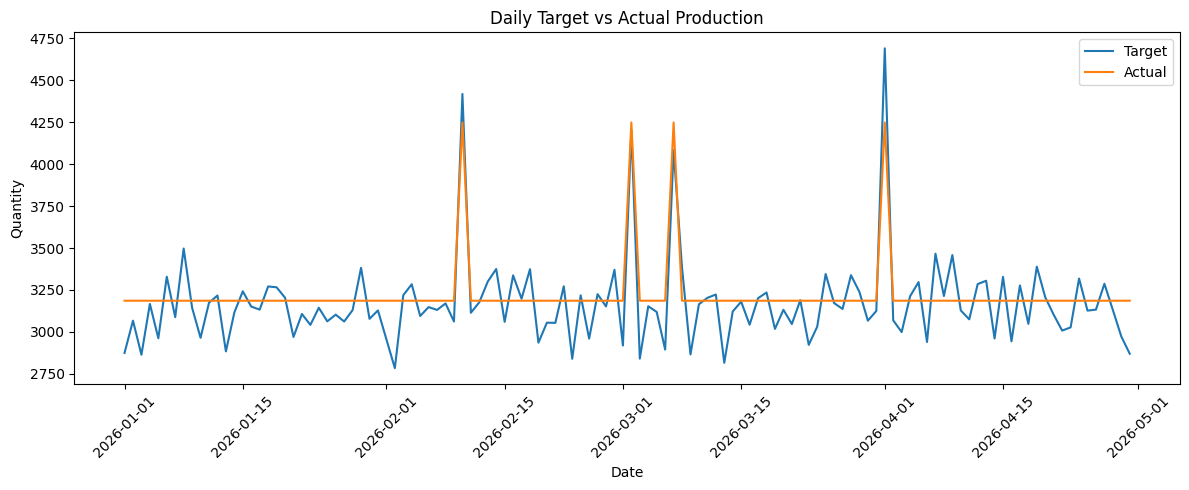

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_production["date"],
    daily_production["target_qty"],
    label="Target"
)

plt.plot(
    daily_production["date"],
    daily_production["actual_qty"],
    label="Actual"
)

plt.title("Daily Target vs Actual Production")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Target production মোটামুটি stable ছিল পুরো 4 মাসে।

কিছু নির্দিষ্ট দিনে target তুলনামূলক বেশি ছিল।

Actual production বেশিরভাগ সময় target-এর উপরে ছিল—যেটা আমাদের overall 101.52% achievement-এর সাথেও consistent।

# Daily Downtime vs Achievement

In [19]:
daily_production = (
    df.groupby("date")
    .agg(
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        good_qty=("good_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum"),
        planned_time_min=("planned_time_min", "sum")
    )
    .reset_index()
)

In [20]:
daily_production["achievement_pct"] = (
    daily_production["actual_qty"]
    / daily_production["target_qty"]
) * 100

In [21]:
daily_production["downtime_pct"] = (
    daily_production["downtime_min"]
    / daily_production["planned_time_min"]
) * 100

In [22]:
daily_production[
    ["date", "achievement_pct", "downtime_pct"]
].head(10)

,date,achievement_pct,downtime_pct
0,2026-01-01,110.817391,10.416667
1,2026-01-02,103.880013,13.888889
2,2026-01-03,111.243017,14.166667
3,2026-01-04,100.599937,7.430556
4,2026-01-05,107.562458,11.736111
5,2026-01-06,95.704416,15.138889
6,2026-01-07,103.173575,15.347222
7,2026-01-08,91.106663,6.111111
8,2026-01-09,101.335878,7.083333
9,2026-01-10,107.453626,8.333333


In [23]:
#Correlation Analysis
daily_production[
    ["achievement_pct", "downtime_pct"]
].corr()

,achievement_pct,downtime_pct
achievement_pct,1.000000,0.178381
downtime_pct,0.178381,1.000000


# Machine-wise Performance

In [24]:
machine_performance = (
    df.groupby("machine")
    .agg(
        production_records=("production_id", "count"),
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        good_qty=("good_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
)

machine_performance

,machine,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min
0,M1,55,59022,58410,57860,550,3490
1,M2,48,49820,50976,50496,480,3338
2,M3,62,63637,65844,65224,620,4301
3,M4,62,64036,65844,65224,620,3867
4,M5,72,76460,76464,75744,720,5141
5,M6,65,67812,69030,68210,820,3921


In [25]:
machine_performance["achievement_pct"] = (
    machine_performance["actual_qty"]
    / machine_performance["target_qty"]
) * 100

machine_performance["reject_rate_pct"] = (
    machine_performance["reject_qty"]
    / machine_performance["actual_qty"]
) * 100

machine_performance["downtime_pct"] = (
    machine_performance["downtime_min"]
    / df.groupby("machine")["planned_time_min"].sum().values
) * 100

machine_performance

,machine,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min,achievement_pct,reject_rate_pct,downtime_pct
0,M1,55,59022,58410,57860,550,3490,98.963099,0.941620,13.219697
1,M2,48,49820,50976,50496,480,3338,102.320353,0.941620,14.487847
2,M3,62,63637,65844,65224,620,4301,103.468108,0.941620,14.452285
3,M4,62,64036,65844,65224,620,3867,102.823412,0.941620,12.993952
4,M5,72,76460,76464,75744,720,5141,100.005231,0.941620,14.875579
5,M6,65,67812,69030,68210,820,3921,101.796142,1.187889,12.567308


M3 → highest achievement (103.47%)

M1 → only machine below 100% achievement (98.96%)

M5 → highest downtime (14.88%)

M6 → highest reject rate (1.19%)

M4-এর downtime তুলনামূলক কম হলেও achievement ভালো।

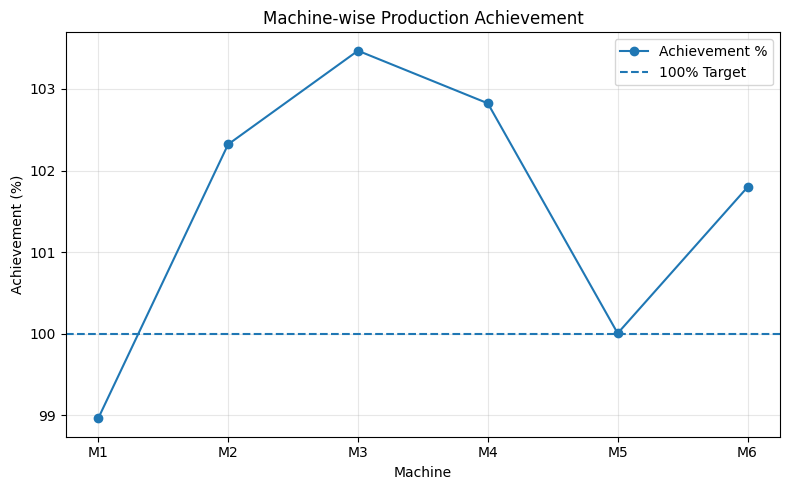

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    machine_performance["machine"],
    machine_performance["achievement_pct"],
    marker="o",
    label="Achievement %"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="100% Target"
)

plt.title("Machine-wise Production Achievement")
plt.xlabel("Machine")
plt.ylabel("Achievement (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Machine Downtime vs Achievement

In [28]:
machine_performance[
    ["machine", "achievement_pct", "downtime_pct"]
]

,machine,achievement_pct,downtime_pct
0,M1,98.963099,13.219697
1,M2,102.320353,14.487847
2,M3,103.468108,14.452285
3,M4,102.823412,12.993952
4,M5,100.005231,14.875579
5,M6,101.796142,12.567308


In [29]:
# machine-level correlation analysis
machine_performance[
    ["achievement_pct", "downtime_pct"]
].corr()

,achievement_pct,downtime_pct
achievement_pct,1.000000,0.035464
downtime_pct,0.035464,1.000000


# Shift-wise Performance

In [30]:
shift_performance = (
    df.groupby("shift")
    .agg(
        production_records=("production_id", "count"),
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        good_qty=("good_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
)

shift_performance

,shift,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min
0,Evening,122,128241,129564,128344,1220,7915
1,Morning,121,127788,128502,127292,1210,8208
2,Night,121,124758,128502,127122,1380,7935


In [31]:
#KPI Analysis by Shift
shift_performance["achievement_pct"] = (
    shift_performance["actual_qty"]
    / shift_performance["target_qty"]
) * 100

shift_performance["reject_rate_pct"] = (
    shift_performance["reject_qty"]
    / shift_performance["actual_qty"]
) * 100

shift_performance["downtime_pct"] = (
    shift_performance["downtime_min"]
    / (
        df.groupby("shift")["planned_time_min"]
        .sum()
        .reindex(shift_performance["shift"])
        .values
    )
) * 100

shift_performance

,shift,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min,achievement_pct,reject_rate_pct,downtime_pct
0,Evening,122,128241,129564,128344,1220,7915,101.031651,0.941620,13.516052
1,Morning,121,127788,128502,127292,1210,8208,100.558738,0.941620,14.132231
2,Night,121,124758,128502,127122,1380,7935,103.001010,1.073913,13.662190


Analytical observation

Night shift সবচেয়ে বেশি production target achieve করেছে:

103.00%

কিন্তু একই সাথে Night shift-এর reject rate সবচেয়ে বেশি (1.07%)।

অর্থাৎ:

Night shift produces more output relative to target, but has slightly higher quality loss.

আর Morning shift:

Lowest achievement → 100.56%
Highest downtime → 14.13%

এখানে একটা সম্ভাব্য operational lead আছে:

Morning shift has the highest downtime and the lowest achievement among the three shifts.


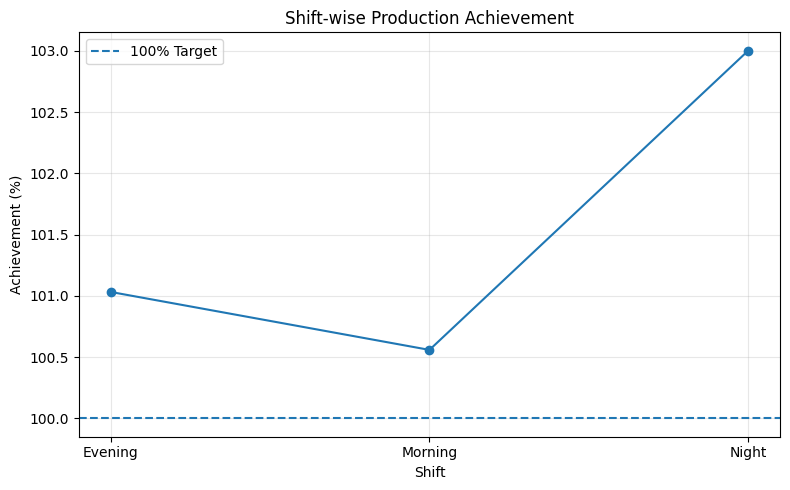

In [32]:
# Visualization of Shift Performance

plt.figure(figsize=(8, 5))

plt.plot(
    shift_performance["shift"],
    shift_performance["achievement_pct"],
    marker="o"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="100% Target"
)

plt.title("Shift-wise Production Achievement")
plt.xlabel("Shift")
plt.ylabel("Achievement (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Product-wise Performance

In [33]:
product_performance = (
    df.groupby("product")
    .agg(
        production_records=("production_id", "count"),
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        good_qty=("good_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
)

product_performance

,product,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min
0,PRODUCT_A,110,116066,116820,115720,1100,7562
1,PRODUCT_B,122,128292,129564,128174,1390,7736
2,PRODUCT_C,132,136429,140184,138864,1320,8760


In [34]:
# KPI Analysis by Product

product_performance["achievement_pct"] = (
    product_performance["actual_qty"]
    / product_performance["target_qty"]
) * 100

product_performance["reject_rate_pct"] = (
    product_performance["reject_qty"]
    / product_performance["actual_qty"]
) * 100

product_performance["downtime_pct"] = (
    product_performance["downtime_min"]
    / (
        df.groupby("product")["planned_time_min"]
        .sum()
        .reindex(product_performance["product"])
        .values
    )
) * 100

product_performance

,product,production_records,target_qty,actual_qty,good_qty,reject_qty,downtime_min,achievement_pct,reject_rate_pct,downtime_pct
0,PRODUCT_A,110,116066,116820,115720,1100,7562,100.649630,0.941620,14.321970
1,PRODUCT_B,122,128292,129564,128174,1390,7736,100.991488,1.072829,13.210383
2,PRODUCT_C,132,136429,140184,138864,1320,8760,102.752347,0.941620,13.825758


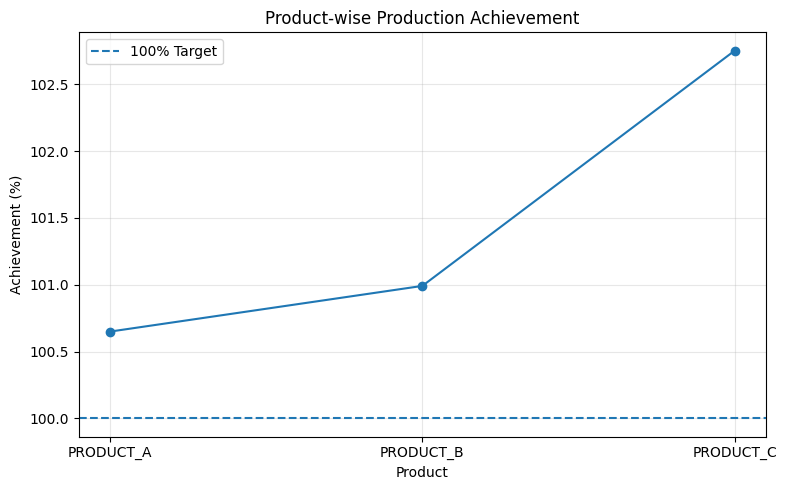

In [35]:
# Visualization of Shift Performance

plt.figure(figsize=(8, 5))

plt.plot(
    product_performance["product"],
    product_performance["achievement_pct"],
    marker="o"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="100% Target"
)

plt.title("Product-wise Production Achievement")
plt.xlabel("Product")
plt.ylabel("Achievement (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Defect Distribution

In [36]:
defect_summary = (
    df["defect_type"]
    .value_counts()
    .reset_index()
)

defect_summary

,defect_type,count
0,No Defect,242
1,Dimension Error,31
2,Scratch,31
3,Color Defect,30
4,Surface Defect,30


In [37]:
#Defect-wise Reject Quantity
defect_reject_summary = (
    df.groupby("defect_type")
    .agg(
        production_records=("production_id", "count"),
        reject_qty=("reject_qty", "sum")
    )
    .reset_index()
    .sort_values("reject_qty", ascending=False)
)

defect_reject_summary

,defect_type,production_records,reject_qty
2,No Defect,242,2420
0,Color Defect,30,470
1,Dimension Error,31,310
3,Scratch,31,310
4,Surface Defect,30,300


In [38]:
df[
    (df["defect_type"] == "No Defect") &
    (df["reject_qty"] > 0)
][
    ["production_id", "product", "reject_qty", "defect_type"]
].head(10)

,production_id,product,reject_qty,defect_type
0,1,PRODUCT_A,10,No Defect
1,2,PRODUCT_C,10,No Defect
3,4,PRODUCT_B,10,No Defect
4,5,PRODUCT_C,10,No Defect
6,7,PRODUCT_B,10,No Defect
7,8,PRODUCT_A,10,No Defect
9,10,PRODUCT_C,10,No Defect
10,11,PRODUCT_B,10,No Defect
12,13,PRODUCT_B,10,No Defect
13,14,PRODUCT_B,10,No Defect


In [39]:
quality_summary = {
    "Good Rate (%)": (
        df["good_qty"].sum()
        / df["actual_qty"].sum()
    ) * 100,

    "Reject Rate (%)": (
        df["reject_qty"].sum()
        / df["actual_qty"].sum()
    ) * 100
}

quality_summary

{'Good Rate (%)': np.float64(99.01440367542062),
 'Reject Rate (%)': np.float64(0.9855963245793754)}

# Downtime Reason Analysis

In [40]:
downtime_reason_summary = (
    df.groupby("downtime_reason")
    .agg(
        production_records=("production_id", "count"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
    .sort_values("downtime_min", ascending=False)
)

downtime_reason_summary

,downtime_reason,production_records,downtime_min
2,Material Shortage,97,6784
1,Maintenance,96,6689
3,Setup/Changeover,64,3893
0,Machine Breakdown,44,2506


Material Shortage → 6,784 min

Maintenance → 6,689 min

Setup/Changeover → 3,893 min

Machine Breakdown → 2,506 min

In [41]:
downtime_reason_summary["downtime_share_pct"] = (
    downtime_reason_summary["downtime_min"]
    / downtime_reason_summary["downtime_min"].sum()
) * 100

downtime_reason_summary

,downtime_reason,production_records,downtime_min,downtime_share_pct
2,Material Shortage,97,6784,34.138486
1,Maintenance,96,6689,33.660427
3,Setup/Changeover,64,3893,19.590378
0,Machine Breakdown,44,2506,12.610709


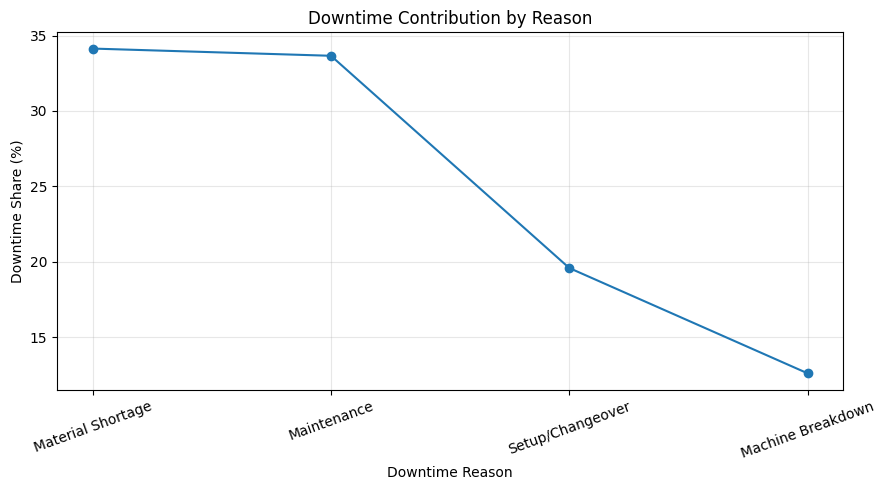

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(
    downtime_reason_summary["downtime_reason"],
    downtime_reason_summary["downtime_share_pct"],
    marker="o"
)

plt.title("Downtime Contribution by Reason")
plt.xlabel("Downtime Reason")
plt.ylabel("Downtime Share (%)")
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Operator-wise Summary

In [43]:
operator_performance = (
    df.groupby("operator_count")
    .agg(
        production_records=("production_id", "count"),
        target_qty=("target_qty", "sum"),
        actual_qty=("actual_qty", "sum"),
        reject_qty=("reject_qty", "sum"),
        downtime_min=("downtime_min", "sum")
    )
    .reset_index()
)

operator_performance["achievement_pct"] = (
    operator_performance["actual_qty"]
    / operator_performance["target_qty"]
) * 100

operator_performance

,operator_count,production_records,target_qty,actual_qty,reject_qty,downtime_min,achievement_pct
0,4,70,73278,74340,700,4495,101.449275
1,5,68,70842,72216,680,4384,101.939527
2,6,86,90701,91332,860,5384,100.695692
3,7,75,78919,79650,750,5615,100.926266
4,8,65,67047,69030,820,4180,102.957627


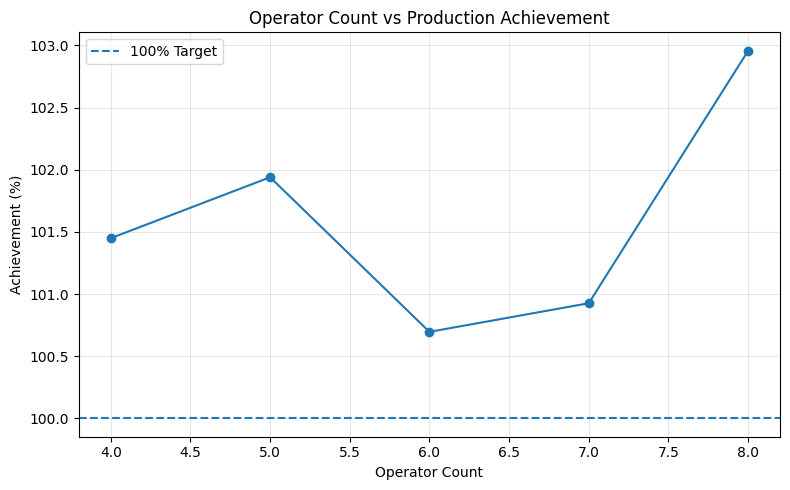

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    operator_performance["operator_count"],
    operator_performance["achievement_pct"],
    marker="o"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="100% Target"
)

plt.title("Operator Count vs Production Achievement")
plt.xlabel("Operator Count")
plt.ylabel("Achievement (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cycle Time Summary

In [45]:
df["cycle_time"].describe()

count    364.000000
mean       0.568736
std        0.127078
min        0.350000
25%        0.460000
50%        0.560000
75%        0.680000
max        0.800000
Name: cycle_time, dtype: float64

In [46]:
cycle_corr = df[
    ["cycle_time", "efficiency_pct"]
].corr()

cycle_corr

,cycle_time,efficiency_pct
cycle_time,1.000000,0.067561
efficiency_pct,0.067561,1.000000


# Final EDA: Top Production Performers

In [47]:
top_production = (
    df[
        [
            "production_id",
            "date",
            "shift",
            "production_line",
            "machine",
            "product",
            "target_qty",
            "actual_qty",
            "efficiency_pct",
            "downtime_min"
        ]
    ]
    .sort_values("efficiency_pct", ascending=False)
    .head(10)
)

top_production

,production_id,date,shift,production_line,machine,product,target_qty,actual_qty,efficiency_pct,downtime_min
168,169,2026-03-13,Evening,L1,M3,PRODUCT_B,900,1062,118.000000,12
254,255,2026-04-16,Night,L3,M6,PRODUCT_B,901,1062,117.869034,114
359,360,2026-01-01,Night,L3,M3,PRODUCT_A,901,1062,117.869034,107
240,241,2026-04-30,Night,L2,M6,PRODUCT_C,903,1062,117.607973,95
49,50,2026-03-12,Morning,L1,M4,PRODUCT_A,904,1062,117.477876,99
333,334,2026-01-27,Night,L3,M6,PRODUCT_C,904,1062,117.477876,102
296,297,2026-03-05,Night,L3,M4,PRODUCT_C,904,1062,117.477876,64
245,246,2026-04-25,Night,L3,M3,PRODUCT_C,905,1062,117.348066,85
144,145,2026-04-06,Evening,L2,M1,PRODUCT_C,905,1062,117.348066,42
194,195,2026-02-15,Evening,L3,M1,PRODUCT_C,905,1062,117.348066,10


Highest achievement 118%

Top 10-এর বেশিরভাগই 117%+

Night shift-এর presence বেশি

কিন্তু downtime-এর variation অনেক বেশি — যেমন 10 min থেকে 114 min পর্যন্ত।

অর্থাৎ আবারও দেখা যাচ্ছে, high achievement মানেই low downtime নয়। আমাদের dataset-এ production output এবং downtime-এর relationship straightforward নয়।

1. Overall Production

Achievement → 101.52%

Good Rate → 99.01%

Reject Rate → 0.99%

2. Daily Performance

Average daily achievement → 101.81%

Range → 90.58%–114.44%

3. Machine Analysis

Best achievement → M3: 103.47%

Lowest → M1: 98.96%

4. Shift Analysis

Best achievement → Night: 103.00%

Highest downtime → Morning: 14.13%

5. Product Analysis

Best achievement → PRODUCT_C: 102.75%

Highest reject rate → PRODUCT_B: 1.07%

6. Downtime Analysis

Material Shortage → 34.14%

Maintenance → 33.66%

Together → 67.80%

7. Operator Analysis

Highest achievement observed with 8 operators → 102.96%

8. Cycle Time

Cycle time vs achievement → very weak correlation (r = 0.068)

9. Downtime vs Achievement

Daily correlation → 0.178

Machine-level correlation → 0.035